# 2. CBC parameters and the two polarisations

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Designed for Google Colab. Run top to bottom; **Extension** sections may be skipped live.


## Source parameters

| Group | Parameters | Main waveform effect |
| --- | --- | --- |
| masses | $m_1,m_2$ or $\mathcal M,q$ | phase evolution and merger frequency |
| spins | $\vec\chi_1,\vec\chi_2$ | phasing, precession, merger |
| matter/orbit | tides, eccentricity | extra phase and harmonics |
| scale | luminosity distance $D_L$ | amplitude $\propto D_L^{-1}$ |
| orientation | inclination $\iota$, polarisation $\psi$ | polarisation content and sky-basis rotation |
| location/time | right ascension $\alpha$, declination $\delta$, $t_c$ | response and arrival delays |
| phase | coalescence phase $\phi_c$ | waveform phase |

Cosmological analyses use detector-frame masses: $m_{\rm det}=(1+z)m_{\rm source}$. This chapter produces radiation before detector projection; Chapter 03 adds the sky and network.

In [1]:
import os, sys, subprocess, importlib.util
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
if importlib.util.find_spec("ripplegw") is None:
    if IN_COLAB: subprocess.check_call([sys.executable,"-m","pip","install","-q","rippleGW==0.2.1"])
    else: raise ImportError("Install rippleGW==0.2.1, or run in Colab.")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from jax import config, jit
config.update("jax_enable_x64", True)
import jax.numpy as jnp
from ripplegw.conversions import ms_to_Mc_eta
from ripplegw.waveforms.IMRPhenomD import gen_IMRPhenomD_hphc
rng=np.random.default_rng(20260817); plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["animation.html"]="jshtml"
frequency=jnp.linspace(20.,512.,985); df=float(frequency[1]-frequency[0]); f_ref=20.
def parameters(m1=36.,m2=29.,chi1=.1,chi2=-.1,distance=400.,tc=0.,phase=0.,inclination=.4):
    chirp_mass,eta=ms_to_Mc_eta(jnp.array([m1,m2]))
    return jnp.array([chirp_mass,eta,chi1,chi2,distance,tc,phase,inclination])
@jit
def waveform(theta): return gen_IMRPhenomD_hphc(frequency,theta,f_ref)
theta_true=parameters(); hp_true,hx_true=waveform(theta_true)
print("chirp mass",round(float(theta_true[0]),3),"solar masses; eta",round(float(theta_true[1]),4))

chirp mass 28.096 solar masses; eta 0.2471


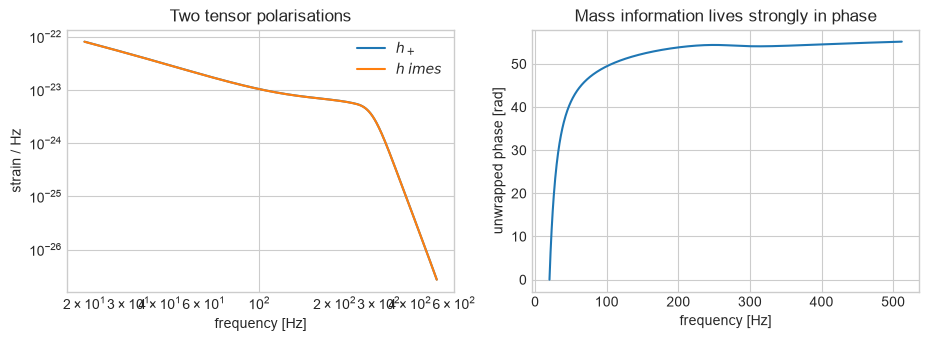

In [3]:
fig,axes=plt.subplots(1,2,figsize=(11,3.4))
axes[0].loglog(np.asarray(frequency),np.abs(np.asarray(hp_true)),label=r"$h_+$")
axes[0].loglog(np.asarray(frequency),np.abs(np.asarray(hx_true)),label=r"$h_	imes$")
axes[0].set(xlabel="frequency [Hz]",ylabel="strain / Hz",title="Two tensor polarisations"); axes[0].legend()
axes[1].plot(np.asarray(frequency),np.unwrap(np.angle(np.asarray(hp_true))))
axes[1].set(xlabel="frequency [Hz]",ylabel="unwrapped phase [rad]",title="Mass information lives strongly in phase"); plt.show()

For a non-precessing circular binary at leading order,
$h_+\propto(1+\cos^2\iota)/(2D_L)$ and $h_\times\propto\cos\iota/D_L$.
Inclination describes the binary relative to the line of sight. Polarisation angle $\psi$ rotates the two axes on the sky; it is a different parameter.

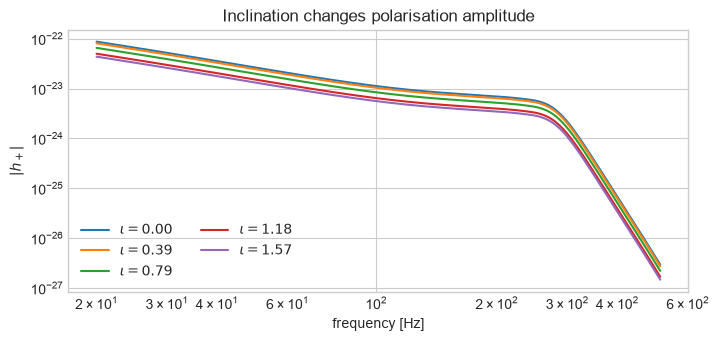

In [4]:
fig,ax=plt.subplots(figsize=(8,3.4))
for iota in np.linspace(0,np.pi/2,5):
    hp,_=waveform(parameters(inclination=float(iota)))
    ax.loglog(np.asarray(frequency),np.abs(np.asarray(hp)),label=fr"$\iota={iota:.2f}$")
ax.set(xlabel="frequency [Hz]",ylabel=r"$|h_+|$",title="Inclination changes polarisation amplitude"); ax.legend(ncol=2); plt.show()

## Animation: chirp mass changes amplitude and phase

In [5]:
frames=np.linspace(18,42,30); fig,(aa,ap)=plt.subplots(1,2,figsize=(11,3.3)); la,=aa.loglog([],[]); lp,=ap.plot([],[])
aa.set(xlim=(20,512),ylim=(2e-25,4e-22),xlabel="frequency [Hz]",ylabel=r"$|h_+|$")
ap.set(xlim=(20,512),ylim=(-250,10),xlabel="frequency [Hz]",ylabel="relative phase [rad]")
def update_mass(i):
    hp,_=waveform(theta_true.at[0].set(frames[i])); h=np.asarray(hp); phase=np.unwrap(np.angle(h)); phase-=phase[0]
    la.set_data(np.asarray(frequency),np.abs(h)); lp.set_data(np.asarray(frequency),phase); fig.suptitle(f"chirp mass = {frames[i]:.1f} solar masses"); return la,lp
animation=FuncAnimation(fig,update_mass,frames=len(frames),interval=130); plt.close(fig); display(HTML(animation.to_jshtml()))

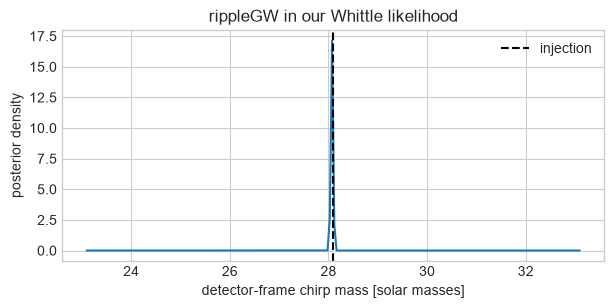

In [6]:
f=np.asarray(frequency); psd=(2.2e-23)**2*((35/f)**4+1+(f/260)**2)
noise=np.sqrt(psd/(4*df))*(rng.normal(size=f.size)+1j*rng.normal(size=f.size)); data=np.asarray(hp_true)+noise
def log_likelihood(model): return -2*df*np.sum(np.abs(data-np.asarray(model))**2/psd)
mass_grid=np.linspace(float(theta_true[0])-5,float(theta_true[0])+5,220)
logp=np.array([log_likelihood(waveform(theta_true.at[0].set(m))[0]) for m in mass_grid])
p=np.exp(logp-logp.max()); p/=np.trapezoid(p,mass_grid)
fig,ax=plt.subplots(figsize=(7,3)); ax.plot(mass_grid,p); ax.axvline(float(theta_true[0]),color="k",ls="--",label="injection")
ax.set(xlabel="detector-frame chirp mass [solar masses]",ylabel="posterior density",title="rippleGW in our Whittle likelihood"); ax.legend(); plt.show()

## Boundary

rippleGW supplied real IMRPhenomD polarisations. The inference still used one polarisation, an analytic PSD, and one free parameter. Next we expose the transformation Bilby normally performs.

- [rippleGW documentation](https://ripplegw.readthedocs.io/)
- [Bilby CBC tutorial](https://bilby-dev.github.io/bilby/compact-binary-coalescence-parameter-estimation.html)